<img src="https://th.bing.com/th/id/R.3cd1c8dc996c5616cf6e65e20b6bf586?rik=09aaLyk4hfbBiQ&riu=http%3a%2f%2fcidics.uanl.mx%2fwp-content%2fuploads%2f2016%2f09%2fcimat.png&ehk=%2b0brgMUkA2BND22ixwLZheQrrOoYLO3o5cMRqsBOrlY%3d&risl=&pid=ImgRaw&r=0" 
     style="float: right; margin-right: 30px;" 
     width="120"
     />

---
 
# **PROCESAMIENTO DEL LENGUAJE NATURAL: TAREA 6: Hierarchical Attention.**
EZAU FARIDH TORRES TORRES.
===
     
<p align="right"> Maestría en Ciencias con Orientación en Matemáticas Aplicadas. </p>
<p align="right"> CENTRO DE INVESTIGACIÓN EN MATEMÁTICAS. </p>
<p align="right"> Fecha de entrega: 11/04/2025. </p>


---

In [1]:
# Necessary libraries.
import numpy as np                             # library for numerical operations.
import matplotlib.pyplot as plt                # library for plotting.
import torch                                   # library for tensor operations.
from nltk.tokenize import TweetTokenizer       # library for tweet tokenization.
from nltk.corpus import stopwords              # library for stopwords.
stopwords_es = set(stopwords.words('spanish')) # set of spanish stopwords.
import os                                      # library for operating system.
import time                                    # library for time.
from typing import Tuple, Callable, List       # library for typing.
import random                                  # library for random numbers.
from sklearn.metrics import classification_report
import pandas as pd                            # library for data manipulation.
from tqdm.notebook import tqdm                 # library for progress bar.
import torch.nn as nn                          # library for neural network operations.
from torch.utils.data import (DataLoader,      # library for data loading.
                              TensorDataset,   # library for tensor dataset.
                              Dataset)         # library for dataset.
from torch.nn.utils.rnn import (pad_packed_sequence,  # for padding.
                                pack_padded_sequence) # for padding.
import torch.nn.functional as F                # library for neural network operations.
from sklearn.metrics import accuracy_score     # library for accuracy score.
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix # library for evaluation.
from torch import nn, optim                    # for neural networks.
from colorama import Fore, Style               # library for colored text.
from sklearn.metrics import f1_score           # for evaluation.
import copy                                    # library for copying.
from itertools import permutations             # library for permutations.
import seaborn as sns                          # library for data visualization.
sns.set_style("darkgrid")                      # set style for seaborn.
import xml.etree.ElementTree as ET             # library for xml parsing.
np.random.seed(0)                              # seed for reproducibility.
random.seed(0)                                 # seed for reproducibility.
torch.manual_seed(0)                           # seed for reproducibility.
torch.backends.cudnn.benchmark = False         # reproducibility.

# **1.- Intrucciones**

La tarea de Author Profiling la podemos ver como un problema de clasificación supervisada para identificar rasgos demográficos (e.g., genero, edad, nacionalidad, rasgos de personalidad, etc.)  de alguna población objetivo. En esta tarea se proporciona un conjunto de datos de perfiles de usuarios de twitter (solo para español). Cada usuario tiene un conjunto de tweets, además tienes un archivo truth.txt en el que encontrarás las etiquetas objetivo. Para esta tarea solamente las de NACIONALIDAD usaremos. Los datos pertenecen a la tarea aquí: https://pan.webis.de/clef17/pan17-web/author-profiling.html

Con PyTorch haga lo siguiente y ESCRIBA UN MUY BREVE comentario para cada punto.

**IMPORTANTE:** Indique CLARAMENTE en cada parte del Notebook dónde se abordan cada uno de los 7 puntos para su revisión.

Sí necesita crear o leer archivos adicionales, entregará todo en una carpeta GDrive a través de un link compartido en classroom en su entrega, y ADEMAS empaquetado en un Zip como archivo con todos los archivos necesarios para correrlo. No olvide poner su NOMBRE al notebook.

P.D. Puede reusar todo el código que quiera del notebook de atención de la escuela de Luis Fernando Pardo.

# **1.- (10pts) Haga el preprocesamiento que usted considere para limpiar y extraer la información de los documentos.**

> Se crea la función *load_data_and_labels()* la cual carga los datos y sus etiquetas usando la librería *xml*. Con esto se cargan los datos de entrenamiento y validación con sus etiquetas correspondientes.

In [2]:
def load_data_and_labels(folder_path: str) -> Tuple[List[str], List[Tuple[str, str]]]:
    """
    Load data and labels from the specified folder. 
    
    Parameters
    ----------
        folder_path : str
            Path to the folder containing the XML files and truth.txt file.

    Returns
    -------
        Tuple[List[str], List[Tuple[str, str]]]
        A tuple containing two lists:
            - data : List[str]
                List of tweets (text data).
            - labels : List[Tuple[str, str]]
                Labels
    """
    # Load labels from truth.txt
    truth_path = os.path.join(folder_path, 'truth.txt') # Path to the truth file.
    id_to_label = {}                                    # Dictionary to store the labels.

    # Read the truth file and store the labels in a dictionary.
    with open(truth_path, 'r', encoding = 'utf-8') as f: # Open the file.
        for line in f:                                   # Read line by line.
            parts = line.strip().split(':::')            # Split the line.
            user_id, gender, country = parts             # Unpack the parts.
            id_to_label[user_id] = (gender, country)     # Store the label.

    data = []   # List to store the data.
    labels = [] # List to store the labels.

    for filename in os.listdir(folder_path):                # Iterate over the files in the folder.
        if filename.endswith('.xml'):                       # Iterate over the XML files in the folder.
            user_id = filename.replace('.xml', '')          # Extract user ID from filename.
            file_path = os.path.join(folder_path, filename) # Construct the full file path.
            
            # Parse the XML file and extract the text.
            tree = ET.parse(file_path)             
            root = tree.getroot() 
            documents = root.find('documents')

            # Check if the documents element exists.
            for doc in documents.findall('document'): # Iterate over the documents.
                text = doc.text                       # Every text is a tweet.
                data.append(text)                     # Append the text to the data list.
                labels.append(id_to_label[user_id])   # Append the label to the labels list.

    return data, labels

# Load data and labels for training and validation sets.
data_train, labels_train = load_data_and_labels(folder_path = 'es_train')
data_val, labels_val = load_data_and_labels(folder_path = 'es_val')

# Number o tweets in training and validation sets.
print(f"Número de tweets en entrenamiento : {len(data_train)}")
print(f"Número de tweets en validación    : {len(data_val)}")
print("")
print(f"Tweet de ejemplo : {data_train[0]}")
print(f"Etiqueta         : {labels_train[0]}")

Número de tweets en entrenamiento : 335998
Número de tweets en validación    : 84000

Tweet de ejemplo : ELN asesina a un policía y meten bomba en su cadáver para matar a más inocentes.Y aún tienen el cinismo de hablar de paz y Navidad.
Etiqueta         : ('female', 'colombia')


> Convertimos los datos a DataFrames y se grafican para averiguar si se tiene algún desbalance de clases y se obtiene que no.

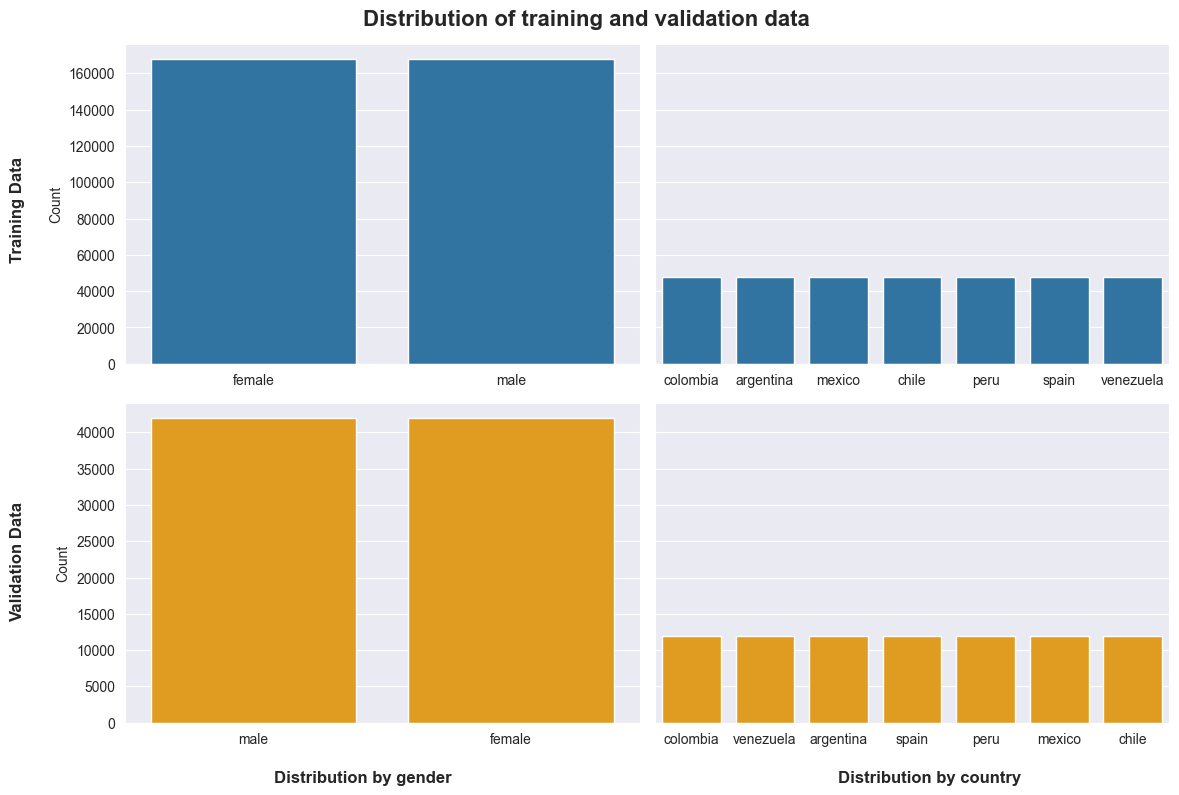

In [3]:
# Create a DataFrame for training and validation data.
df_train = pd.DataFrame(
    labels_train, columns = ["gender", "country"], index = range(1, len(labels_train) + 1))
df_val = pd.DataFrame(
    labels_val, columns = ["gender", "country"], index = range(1, len(labels_val) + 1))

# Graphs for training and validation data.
fig, axs = plt.subplots(2, 2, figsize = (12,8), sharey = 'row')
fig.suptitle('Distribution of training and validation data', fontsize = 16, weight = 'bold')

# Graphs for training data.
sns.countplot(data = df_train, x = "gender", ax = axs[0,0])
sns.countplot(data = df_train, x = "country", ax = axs[0,1])

# Graphs for validation data.
sns.countplot(data = df_val, x = "gender", ax = axs[1,0], color = "orange")
sns.countplot(data = df_val, x = "country", ax = axs[1,1], color = "orange")

# Set the title for each subplot.
for ax in axs.flatten():
    ax.set_xlabel("")
axs[0,0].set_ylabel("Count")
axs[0,1].set_ylabel("")
axs[1,0].set_ylabel("Count")
axs[1,1].set_ylabel("")

# Labels for the axes.
fig.text(0.71, 0.02, 'Distribution by country', va = 'center', rotation = 'horizontal', fontsize = 12, weight = 'bold')
fig.text(0.24, 0.02, 'Distribution by gender', va = 'center', rotation = 'horizontal', fontsize = 12, weight = 'bold')
fig.text(0.02, 0.73, 'Training Data', va = 'center', rotation = 'vertical', fontsize = 12, weight = 'bold')
fig.text(0.02, 0.29, 'Validation Data', va = 'center', rotation = 'vertical', fontsize = 12, weight = 'bold')

plt.tight_layout(rect = [0.04, 0.04, 1, 1])
plt.show()

> Para este problema de clasificación, codificamos las etiquetas por género y país en diccionarios:

In [4]:
# Create the
gender_map = {gender: idx for idx, gender in enumerate(df_train["gender"].unique())}
country_map = {country: idx for idx, country in enumerate(df_train["country"].unique())}

print("Gender Map:", gender_map)
print("Country Map:", country_map)

Gender Map: {'female': 0, 'male': 1}
Country Map: {'colombia': 0, 'argentina': 1, 'mexico': 2, 'chile': 3, 'peru': 4, 'spain': 5, 'venezuela': 6}


>Usando la librería *Dataset*, se crea la clase *AuthorProfilingDataset* la cual recibe el corpus en crudo y los labels creados anteriormente y se usa una estructura bastante similar a la usada en el notebook de la escuela. Es opcional eliminar las stopwords y se añaden los diccionarios creados.
>
>- Se define el método estático *load_vocab_embeddings()*, el cual carga el vocabulario y sus vectores de palabras preentrenados desde el archivo 'word2vec_col.txt' y devuelve un diccionario que asigna cada palabra a un índice entero y una matriz donde cada fila es el vector de embeddings correspondiente al índice del vocabulario. Además, se agrega un vector de ceros para representar el padding ('pad') y un vector promedio de todos los embeddings para representar palabras desconocidas ('unk').
>
>- En *preprocessed_text()* se hace un preprocesamiento de los datos, se usa *TweetTokenizer()* en lugar de *word_tokenize()* como tokenizador default.
>
>- Se adaptaron los métodos *\_\_getitem\_\_()* y *collate_fn()* para manejar los labels en formato *('género', 'país')* en lugar de {0,1}.

In [5]:
class AuthorProfilingDataset(Dataset):
    def __init__(self, corpus: List[str], labels: List[Tuple[str, str]], tokenizer: Callable = None,
                 remove_stopwords: bool = False, stopwords_set: set = stopwords_es,
                 gender_map: dict = gender_map, country_map: dict = country_map):
        """
        Initialize the dataset.
        
        Parameters
        ----------
        corpus : list
            List of text data (tweets).
        labels : list
            List of labels
        tokenizer : callable, optional
            Tokenizer for text processing. If None, a default tokenizer is used.
        remove_stopwords : bool, optional
            Whether to remove stopwords. Default is False.
        stopwords_set : set, optional
            Set of stopwords to be removed. Default is Spanish stopwords.
        gender_map : dict
            Dictionary that maps labels to their encoding.
        country_map : dict
            Dictionary that maps labels to their encoding.
        """
        # Initialize the dataset.
        self.corpus = corpus
        self.labels = labels

        # Label maps.
        self.gender_map = gender_map
        self.country_map = country_map

        # Load the vocabulary and embeddings.
        self.vocab, self.emb_mat = AuthorProfilingDataset.load_vocab_embeddings()

        # Tokenizer for text processing and additional parameters.
        self.tokenizer = tokenizer if tokenizer else TweetTokenizer(preserve_case = False, reduce_len = True, strip_handles = True)
        self.remove_stopwords = remove_stopwords
        self.stopwords = stopwords_set

    def __len__(self) -> int:
        """
        Get the length of the dataset.
        """
        return len(self.corpus)

    @staticmethod
    def load_vocab_embeddings() -> Tuple[dict, np.ndarray]:
        """
        Load the vocabulary and pre-trained embeddings. It uses the word2vec model.
        The embeddings are stored in a file called 'word2vec_col.txt'.

        Returns
        -------
        tuple
            A tuple containing the vocabulary and embeddings matrix.
        """
        embeddings_list = []
        vocab = {}
        with open('word2vec_col.txt', 'r') as f:
            for i, line in enumerate(f):
                if i != 0:
                    values = line.split()
                    vocab[values[0]] = i + 1
                    vector = np.asarray(values[1:], dtype = "float32")
                    embeddings_list.append(vector)
        embeddings_list.insert(0, np.mean(np.vstack(embeddings_list), axis = 0)) # Mean vector for unk
        embeddings_list.insert(0, np.zeros(100))                                 # Padding vector
        vocab['pad'] = 0
        vocab['unk'] = 1
        emb_mat = np.vstack(embeddings_list)
        return vocab, emb_mat
    
    def preprocessed_text(self, text: str) -> Tuple[List[str], List[int]]:
        """
        Preprocess the text. 

        Parameters
        ----------
        text : str
            The text to be preprocessed.
        
        Returns
        -------
        tuple
            A tuple containing the list of tokens (words) and their corresponding IDs.
        """
        words = self.tokenizer.tokenize(text.lower())
        if self.remove_stopwords:
            words = [word for word in words if word not in self.stopwords]
        word_ids = [self.vocab[word] if word in self.vocab else self.vocab['unk'] for word in words]

        return words, word_ids
    
    def __getitem__(self, index: int) -> Tuple[torch.Tensor, Tuple[int, int], List[str]]:
        """
        Get the item at the specified index. 

        Parameters
        ----------
        index : int
            The index of the item.
        
        Returns
        -------
        tuple
            A tuple containing the word ids, labels, and words from the index given.
        """
        text = self.corpus[index]
        gender_str, country_str = self.labels[index]

        gender_id = self.gender_map[gender_str]
        country_id = self.country_map[country_str]

        words, word_ids = self.preprocessed_text(text)
        return word_ids, (gender_id, country_id), words
    
    @staticmethod
    def collate_fn(batch: List[Tuple[torch.Tensor, Tuple[int, int], List[str]]]) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, List[str]]:
        """
        Collate function to pad the sequences and create mini-batches. This function is used to combine multiple
        samples into a single batch. It pads the sequences to the same length and returns the batch data. The
        batch is a list of tuples, where each tuple contains the word ids, labels, and words. The function pads
        the sequences to the same length and returns the batch data.

        Parameters
        ----------
        batch : list
            A list containing the data.
        
        Returns
        -------
        tuple
            A tuple containing the word ids, lengths, labels and words.
            - word_ids : torch.Tensor
                The padded word ids.
            - lengths : torch.Tensor
                The lengths of the sequences.
            - labels : tuple
                The labels for the sequences.
            - words : list
                The words from the sequences.
        """
        # Unzip the batch into separate lists.
        zipped_batch = list(zip(*batch))

        # Pad the sequences to the same length.
        word_ids = [torch.tensor(t) for t in zipped_batch[0]]
        word_ids = torch.nn.utils.rnn.pad_sequence(word_ids, batch_first = True, padding_value = 0)
        lengths = torch.tensor([len(t) for t in zipped_batch[0]])

        # Get the labels.
        genders, countries = zip(*zipped_batch[1])
        gender_labels = torch.tensor(genders)
        country_labels = torch.tensor(countries)

        # Get the words.
        words = zipped_batch[2]
        return word_ids, lengths, (gender_labels, country_labels), words

# **2.- (40pts) Diseñe un clasificador con alguna RNN con atención en jerárquia (como en el paper adjunto) que codifique cada perfil de usuario con todos sus tweets y clasifique. El primer nivel intuitivamente recibe embeddings de palabras, el segundo nivel de atención modela los tweets. Preinicialice su red con los embeedings w2v proporcionados.**

> Debido a que sí se hará una comparación de modelos en el punto 7, comenzaremos definiendo las clases generales:
> 1. 

In [ ]:
class Trainer:
    def __init__(
            self, model: nn.Module, epochs: int, train_dataset: Dataset, train_dataloader: DataLoader,
            val_dataloader: DataLoader, device: str, lambdas: List[float] = [1.0, 1.0], lr: float = 1e-3, patience: int = 5,
            weight_decay: float = 1e-4, betas: Tuple[float, float] = (0.9, 0.999), lr_patience: int = 3, lr_factor: float = 0.1,
            checkpoint_path: str = 'trained_model', checkpoint_filename: str = 'checkpoint.pth',
            best_model_filename: str = 'best_model.pth'
    ):
        """
        Initialize the Trainer class.
        
        Parameters
        ----------
        model : nn.Module
            The model to be trained.
        epochs : int
            Number of epochs for training.
        train_dataset : Dataset
            The training dataset.
        train_dataloader : DataLoader
            DataLoader for the training dataset.
        val_dataloader : DataLoader
            DataLoader for the validation dataset.
        device : str
            The device to be used for training (CPU or GPU).
        lambdas : list, optional
            List of weights for the loss functions. Default is [1.0, 1.0].
        lr : float, optional
            Learning rate for the optimizer. Default is 1e-3.
        patience : int, optional
            Number of epochs with no improvement after which training will be stopped. Default is 5.
        weight_decay : float, optional
            Weight decay for the optimizer. Default is 1e-4.
        betas : tuple, optional
            Betas for the optimizer. Default is (0.9, 0.999).
        """
        # Initialize the trainer.
        self.model = model.to(device) # Move the model to the specified device.
        self.epochs = epochs
        self.train_dataset = train_dataset
        self.train_dataloader = train_dataloader
        self.val_dataloader = val_dataloader
        self.device = device
        self.lambdas = lambdas
        self.lr = lr
        self.patience = patience
        self.weight_decay = weight_decay
        self.betas = betas
        self.lr_patience = lr_patience
        self.lr_factor = lr_factor

        # Checkpoint parameters.
        self.checkpoint_path     = checkpoint_path
        self.checkpoint_filename = checkpoint_filename
        self.best_model_filename = best_model_filename

        self.train_loss_history = []   # Training loss history.
        self.val_loss_history   = []   # Validation loss history.
        self.f1_gender_history  = []   # f1 metric history for gender.
        self.f1_country_history = []   # f1 metric history for country.
        self.best_val_f1        = 0    # Best f1 metric in validation set.
        self.n_no_improvement   = 0    # Number of epochs without improvement.
        self.best_state_dict    = None # Store the best model state dict.

        # Optimizer.
        self.optimizer = optim.Adam(
            model.parameters(),
            lr = self.lr,
            weight_decay = self.weight_decay,
            betas = self.betas
        )

        # Scheduler.
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,              # optimizer to adjust.
            mode = 'min',                # mode (min means reduce when the quantity monitored has stopped decreasing).
            patience = self.lr_patience, # patience (number of epochs with no improvement after which learning rate will be reduced).
            factor = self.lr_factor      # factor by which the learning rate will be reduced. new_lr = lr * factor.
        )

        # Loss function.
        self.criterion_gender = nn.CrossEntropyLoss()
        self.criterion_country = nn.CrossEntropyLoss()

    def loss_function(self, gender_logits: torch.Tensor, country_logits: torch.Tensor,
                      gender_labels: torch.Tensor, country_labels: torch.Tensor) -> torch.Tensor:
        """
        Compute the loss for the multitask model.

        Parameters
        ----------
        gender_logits : torch.Tensor
            Raw logits for gender.
        country_logits : torch.Tensor
            Raw logits for country.
        gender_labels : torch.Tensor
            Labels for gender.
        country_labels : torch.Tensor
            Labels for country.
        
        Returns
        -------
        torch.Tensor
            The computed loss.
        """
        loss_gender = self.criterion_gender(gender_logits, gender_labels)
        loss_country = self.criterion_country(country_logits, country_labels)
        loss = self.lambdas[0]*loss_gender + self.lambdas[1]*loss_country
        return loss

    def eval_model(self, dataloader: DataLoader) -> Tuple[float, float, float, List[float],
                                                          List[float], List[int], List[int],
                                                          List[int], List[int], List[str]
                                                          ]:
        """
        Evaluates the multitask model.

        Parameters
        ----------
        dataloader : DataLoader
            DataLoader for the evaluation dataset.

        Returns
        -------
        tuple
            A tuple containing:
            - average loss,
            - F1 score for gender and country,
            - scores
            - predictions for gender and country,
            - real labels
        """
        with torch.no_grad():
            self.model.eval() # Set the model to evaluation mode.
            losses = []       # List to store the losses.

            # Gender.
            preds_gender   = [] # List to store the predictions.
            targets_gender = [] # List to store the targets.
            scores_gender  = [] # List to store the scores.

            # Country.
            preds_country   = [] # List to store the predictions.
            targets_country = [] # List to store the targets.
            scores_country  = [] # List to store the scores.

            words_list = [] # List to store the words.
    
            # Iterate over the batches.
            for data in tqdm(dataloader, desc = 'Evaluation...', colour = 'deepskyblue'):
                torch.cuda.empty_cache() # Clear the cache.
    
                seq, seq_len, (gender_labels, country_labels), words = data # Output of the dataloader.
                seq, gender_labels, country_labels = seq.to(self.device), gender_labels.to(self.device), country_labels.to(self.device)
    
                # Forward pass.
                gender_logits, country_logits = self.model(seq, seq_len)
                
                # Calculate the loss.
                loss_per_batch = self.loss_function(gender_logits, country_logits, gender_labels, country_labels)
                losses.append(loss_per_batch.item())
    
                # Predictions and targets.
                gender_pred = gender_logits.argmax(dim = 1)   # Prediction of the batch for gender.
                country_pred = country_logits.argmax(dim = 1) # Prediction of the batch for country.
            
                preds_gender += gender_pred.cpu().tolist()
                targets_gender += gender_labels.cpu().tolist()

                # Probabilities using softmax (for score/confidence tracking)
                probs_gender = torch.softmax(gender_logits, dim = 1)
                scores_gender += probs_gender[:,1].cpu().tolist()  # Assuming class 1 = "female" or positive class

                probs_country = torch.softmax(country_logits, dim = 1)
                scores_country += probs_country.max(dim = 1)[0].cpu().tolist()  # Max prob for the predicted country

                preds_country += country_pred.cpu().tolist()
                targets_country += country_labels.cpu().tolist()

                words_list += words

            # F1 scores
            f1_gender = f1_score(targets_gender, preds_gender, average = 'binary')
            f1_country = f1_score(targets_country, preds_country, average = 'macro')

            return (
                np.mean(losses),
                f1_gender, f1_country,
                scores_gender, scores_country,
                preds_gender, preds_country,
                targets_gender, targets_country,
                words_list
            )

    def train(self):
        """
        Train the model.
        """
        start_time = time.time() # Start time of the training.

        for epoch in range(1, self.epochs + 1):
            self.model.train()
            loss_train = 0
            epoch_time = time.time() # Start time of the epoch.
    
            for data in tqdm(self.train_dataloader, desc = 'Training...', colour = 'green'):
                torch.cuda.empty_cache()   # Clear the cache.
                self.optimizer.zero_grad() # Zero the gradients.
    
                seq, seq_len, (gender_labels, country_labels), _ = data # Output of the dataloader.
                seq, gender_labels, country_labels = seq.to(self.device), gender_labels.to(self.device), country_labels.to(self.device)
    
                gender_logits, country_logits = self.model(seq, seq_len) # Forward pass.
    
                # Calculate the loss.
                loss_per_batch = self.loss_function(gender_logits, country_logits, gender_labels, country_labels)
    
                # Backward pass and optimization.
                loss_per_batch.backward()
                self.optimizer.step()
                loss_train += loss_per_batch.item()
    
            # Average loss for the epoch.
            loss_train /= len(self.train_dataloader)
    
            # Evaluate the model on the validation set.
            val_results = self.eval_model(self.val_dataloader)
            val_loss = val_results[0]       # Average loss.
            val_f1_gender = val_results[1]  # F1 score for gender.
            val_f1_country = val_results[2] # F1 score for country.

            # Store the results.
            self.train_loss_history.append(loss_train)
            self.val_loss_history.append(val_loss)
            self.f1_gender_history.append(val_f1_gender)
            self.f1_country_history.append(val_f1_country)
    
            # Sum of F1 scores to determine the best model.
            val_f1 = val_f1_gender + val_f1_country
            is_improvement = val_f1 > self.best_val_f1
            
            if is_improvement:
                self.best_val_f1 = val_f1
                self.best_time = time.time() - start_time
                self.best_epoch = epoch
                self.n_no_improvement = 0
            else:
                self.n_no_improvement += 1

            # Save checkpoint.
            elapsed_time = time.time() - start_time # Elapsed time since the start of training.
            self.save_checkpoint(
                state =
                {
                    # This epoch information.
                    'epoch'           : epoch,
                    'state_dict'      : self.model.state_dict(),
                    'loss_train'      : loss_train,
                    'loss_val'        : val_loss,
                    'elapsed_time'    : elapsed_time,
                    # Best information.
                    'best_val_f1'     : self.best_val_f1,
                    'best_epoch'      : self.best_epoch,
                    'best_time'       : self.best_time,
                    # History information.
                    'train_loss_history' : self.train_loss_history,
                    'val_loss_history'   : self.val_loss_history,
                    'f1_gender_history'  : self.f1_gender_history,
                    'f1_country_history' : self.f1_country_history,
                },
                is_best = is_improvement
            )

            # Early stopping.
            if self.n_no_improvement >= self.patience:
                tqdm.write(f"{Fore.RED}Early stopping triggered at epoch {epoch}!{Style.RESET_ALL}")
                break
            elif loss_train < 1e-5:
                tqdm.write(f"{Fore.RED}Loss is too low, stopping training!{Style.RESET_ALL}")
                break
    
            # Print the results.
            tqdm.write(f"{Style.BRIGHT} Epoch{epoch:>3}/{self.epochs}{Style.RESET_ALL}"
                       f"  ➤ Training loss: {Fore.GREEN}{loss_train:.4f}{Style.RESET_ALL} | "
                       f"Validation Loss: {Fore.YELLOW}{val_loss:.4f}{Style.RESET_ALL} | "
                       f"F1 Gender: {Fore.CYAN}{val_f1_gender:.4f}{Style.RESET_ALL} | "
                       f"F1 Country: {Fore.MAGENTA}{val_f1_country:.4f}{Style.RESET_ALL} | "
                       f"Epoch Time: {time.time() - epoch_time:.2f} s | "
                       f"Total Time: {elapsed_time:.2f} s")
            
        print(f"\n{Style.BRIGHT}--- Total Training Time: {elapsed_time:.2f} seconds ---{Style.RESET_ALL}")

    def save_checkpoint(self, state: dict, is_best: bool) -> None:
        """
        Save a checkpoint of the model, including the state dictionary, training metadata,
        optimizer state, and the initialization parameters used to construct the model.

        Parameters
        ----------
        state : dict
            Dictionary with the model state, best model state, loss histories, and optimizer state.
        is_best : bool
            If True, also save the model as the best checkpoint.
        """
        if not os.path.exists(self.checkpoint_path):
            os.makedirs(self.checkpoint_path, exist_ok = True)

        if is_best:
            state['best_model_state_dict'] = self.model.state_dict()

        filepath = os.path.join(self.checkpoint_path, self.checkpoint_filename)
        torch.save(state, filepath)

        if is_best:
            best_path = os.path.join(self.checkpoint_path, self.best_model_filename)
            torch.save({'best_model_state_dict': self.model.state_dict()}, best_path)

    def plot_metrics(self):
        epochs = list(range(1, len(self.train_loss_history) + 1))
    
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Dos gráficas lado a lado
    
        # --- Gráfico de pérdida ---
        axes[0].plot(epochs, self.train_loss_history, label='Training Loss', color='#1f77b4')
        axes[0].plot(epochs, self.val_loss_history, label='Validation Loss', color='#ff7f0e')
        axes[0].axvline(self.best_epoch, linestyle="--", color="gray", alpha=0.7, label=f"Best Epoch: {self.best_epoch}")
        axes[0].set_title('Loss over Epochs', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Epochs', fontsize=12)
        axes[0].set_ylabel('Loss', fontsize=12)
        axes[0].legend(fontsize=12)
        axes[0].grid()
    
        # --- Gráfico de F1 ---
        axes[1].plot(epochs, self.f1_gender_history, label='F1 Gender', color='#2ca02c')
        axes[1].plot(epochs, self.f1_country_history, label='F1 Country', color='#d62728')
        axes[1].axvline(self.best_epoch, linestyle="--", color="gray", alpha=0.7, label=f"Best Epoch: {self.best_epoch}")
        axes[1].set_title('F1 Score over Epochs', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Epochs', fontsize=12)
        axes[1].set_ylabel('F1 Score', fontsize=12)
        axes[1].legend(fontsize=12)
        axes[1].grid()
    
        plt.tight_layout()
        plt.show()

In [ ]:
class Evaluation:
    @staticmethod
    def plot_confusion_matrices(y_true_gender, y_pred_gender, gender_labels,
                                 y_true_country, y_pred_country, country_labels):
        """
        Display side-by-side confusion matrices for gender and country classification.

        Parameters
        ----------
        y_true_gender : list or array
            True gender labels.
        y_pred_gender : list or array
            Predicted gender labels.
        gender_labels : list of str
            Class names for gender.

        y_true_country : list or array
            True country labels.
        y_pred_country : list or array
            Predicted country labels.
        country_labels : list of str
            Class names for country.
        """
        fig, axes = plt.subplots(1, 2, figsize = (14, 5))

        # Gender Confusion Matrix
        cm_gender = confusion_matrix(y_true_gender, y_pred_gender)
        sns.heatmap(cm_gender, annot=True, fmt='d', cmap='Purples',
                    xticklabels=gender_labels, yticklabels=gender_labels, ax=axes[0])
        axes[0].set_title("Confusion Matrix: Gender")
        axes[0].set_xlabel("Predicted Label")
        axes[0].set_ylabel("True Label")

        # Country Confusion Matrix
        cm_country = confusion_matrix(y_true_country, y_pred_country)
        sns.heatmap(cm_country, annot=True, fmt='d', cmap='Purples',
                    xticklabels=country_labels, yticklabels=country_labels, ax=axes[1])
        axes[1].set_title("Confusion Matrix: Country")
        axes[1].set_xlabel("Predicted Label")
        axes[1].set_ylabel("True Label")

        plt.tight_layout()
        plt.show()

    #@staticmethod
    #def evaluate_best_model(trainer, train_dataloader: DataLoader, val_dataloader: DataLoader,
    #                        filename: str = "trained_model/best_model.pth") -> Tuple:
    @staticmethod
    def evaluate_best_model(trainer,train_dataloader, val_dataloader, filename: str = "trained_model/best_model.pth"):
        """
        Evaluate the best trainer on the training and validation sets.

        Parameters
        ----------
        train_dataloader : DataLoader
            DataLoader for the training set.
        val_dataloader : DataLoader
            DataLoader for the validation set.
        results : bool, optional
            Whether to return the results. Default is True.
        
        Returns
        -------
        tuple
            A tuple containing the evaluation results for the training and validation sets.
        """
        checkpoint = torch.load(filename, map_location = 'cpu', weights_only = True)
        trainer.model.load_state_dict(checkpoint['best_model_state_dict'])  # ✅        
        trainer.model.eval()                                # Set the trainer to evaluation mode.
        
        print("\nEvaluando en conjunto de entrenamiento:")
        train_eval = trainer.eval_model(train_dataloader)
        train_loss, f1_gender_train, f1_country_train = train_eval[:3]

        print("\nEvaluando en conjunto de validación:")
        val_eval = trainer.eval_model(val_dataloader)
        val_loss, f1_gender_val, f1_country_val = val_eval[:3]

        print(f"\nTrain Loss : {train_loss:.4f} | F1 Gender: {f1_gender_train:.4f} | F1 Country: {f1_country_train:.4f}")
        print(f"Val Loss   : {val_loss:.4f} | F1 Gender: {f1_gender_val:.4f} | F1 Country: {f1_country_val:.4f}")

        train_results = {
            "loss"            : train_loss,
            "f1_gender"       : f1_gender_train,
            "f1_country"      : f1_country_train,
            "scores_gender"   : train_eval[3],
            "scores_country"  : train_eval[4],
            "preds_gender"    : train_eval[5],
            "preds_country"   : train_eval[6],
            "targets_gender"  : train_eval[7],
            "targets_country" : train_eval[8],
            "words"           : train_eval[9],
            }
        
        val_results = {
            "loss"            : val_loss,
            "f1_gender"       : f1_gender_val,
            "f1_country"      : f1_country_val,
            "scores_gender"   : val_eval[3],
            "scores_country"  : val_eval[4],
            "preds_gender"    : val_eval[5],
            "preds_country"   : val_eval[6],
            "targets_gender"  : val_eval[7],
            "targets_country" : val_eval[8],
            "words"           : val_eval[9],
            }

        print("\nPer-class report for Gender:")
        print(classification_report(val_results['targets_gender'], val_results['preds_gender'], target_names = ['Male', 'Female']))

        print("\nPer-class report for Country:")
        print(classification_report(val_results['targets_country'], val_results['preds_country']))

        # Labels for gender (adjust if needed)
        gender_labels = ['Male', 'Female']

        # Define country labels in correct order
        country_labels = [label for label, idx in sorted(trainer.train_dataset.country_map.items(), key=lambda x: x[1])]

        # Plot the confusion matrices
        Evaluation.plot_confusion_matrices(
            val_results['targets_gender'], val_results['preds_gender'], gender_labels,
            val_results['targets_country'], val_results['preds_country'], country_labels
        )

        return train_results, val_results

In [6]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size: int = 100, hidden_size: int = 50, num_layers: int = 1,
                 bidirectional: bool = False, emb_mat: np.ndarray = None, dense_hidden_size: int = 50,
                 num_genres: int = len(gender_map), num_countries: int = len(country_map)):
        """
        Initialize the SimpleRNN model.

        Parameters
        ----------
        input_size : int
            Size of the input embeddings.
        hidden_size : int
            Size of the hidden state of the GRU.
        num_layers : int
            Number of layers in the GRU.
        bidirectional : bool
            Whether to use a bidirectional GRU.
        emb_mat : np.ndarray
            Pre-trained embeddings matrix.
        dense_hidden_size : int
            Size of the hidden layer in the classifier.
        num_genres : int
            Number of genres (labels).
        num_countries : int
            Number of countries (labels).
        """
        # Initialize the model.
        super(SimpleRNN, self).__init__()
        
        # Trainable embeddings matrix, size vocab_size x 100.
        self.embeddings = nn.Embedding.from_pretrained(
            torch.FloatTensor(emb_mat),
            freeze = False
        )
        
        # Gated Recurrent Unit.
        self.gru = nn.GRU(
            input_size    = input_size,
            hidden_size   = hidden_size, 
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = bidirectional
        )
        
        directions = 2 if bidirectional else 1 # Number of directions of the GRU.

        self.classifier_gender = nn.Sequential(
            nn.Linear(hidden_size * directions, dense_hidden_size),
            nn.BatchNorm1d(dense_hidden_size),
            nn.ReLU(),
            nn.Linear(dense_hidden_size, num_genres)
        )

        self.classifier_country = nn.Sequential(
            nn.Linear(hidden_size * directions, dense_hidden_size),
            nn.BatchNorm1d(dense_hidden_size),
            nn.ReLU(),
            nn.Linear(dense_hidden_size, num_countries)
        )

    def forward(self, input_seq: torch.Tensor, lengths: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass of the model.

        Parameters
        ----------
        input_seq : torch.Tensor
            Input sequence of word ids.
        lengths : torch.Tensor
            Lengths of the sequences in the batch.

        Returns
        -------
        tuple
            A tuple containing the logits (not softmaxed yet) for gender and country prediction.
        """
        # Converts word IDs into dense vectors using the embedding layer.
        x = self.embeddings(input_seq)                      

        # Sort the sequences by length in descending order.
        lengths, perm_idx = lengths.sort(descending = True) 
        x = x[perm_idx]                                         
        
        # Converts padded sequences into a packed format, improving RNN efficiency and avoiding processing padding.
        x = pack_padded_sequence(x, lengths, batch_first = True, enforce_sorted = True)
        
        # GRU processing.
        packed_output, hn = self.gru(x) # For a multi-layer or bidirectional GRU, hn contains several layers/directions.

        # Unpack the sequences.
        output, _ = pad_packed_sequence(packed_output, batch_first = True) # Unpack the sequences.

        # Unsort to original batch order.
        _, unperm_idx = perm_idx.sort() # Get the indexes to unsort.
        output = output[unperm_idx]     # Unsort the sequences.
        hn = hn[:, unperm_idx]          # Unsort the hidden states.

        # Get final hidden state.
        final_output = hn[-1]

        # Run through classifiers.
        logits_gender = self.classifier_gender(final_output)
        logits_country = self.classifier_country(final_output)
        
        return logits_gender, logits_country

In [9]:
# Create the datasets.
train_dataset = AuthorProfilingDataset(data_train, labels_train, gender_map = gender_map, country_map = country_map)
val_dataset = AuthorProfilingDataset(data_val, labels_val, gender_map = gender_map, country_map = country_map) 

# Create the dataloaders.
batch_size = 128
train_dataloader = DataLoader(train_dataset, batch_size = batch_size, collate_fn = train_dataset.collate_fn, shuffle = True)
val_dataloader = DataLoader(val_dataset, batch_size = batch_size, collate_fn = val_dataset.collate_fn, shuffle = False)

In [10]:
# Parameters for the model.
device = 'cuda' if torch.cuda.is_available() else 'cpu'
params_RNN = {
    'input_size'        : 100,              # Size of the input embeddings.
    'hidden_size'       : 50,               # Size of the hidden state of the GRU.
    'num_layers'        : 1,                # Number of layers in the GRU.
    'bidirectional'     : False,            # Whether to use a bidirectional GRU.
    'dense_hidden_size' : 50,               # Size of the hidden layer in the classifier.
    'num_genres'        : len(gender_map),  # Number of genres (labels).
    'num_countries'     : len(country_map), # Number of countries (labels).
}
params_train = {
    'epochs'            : 1,                # Number of epochs.
    'train_dataset'     : train_dataset,    # Training dataset.
    'train_dataloader'  : train_dataloader, # Training dataloader.
    'val_dataloader'    : val_dataloader,   # Validation dataloader.
    'device'            : device,           # Device to use (CPU or GPU).
    'lambdas'           : [1.0, 1.0],       # Weights for the loss function.
    'lr'                : 1e-3,             # Learning rate.
    'patience'          : 5,                # Number of epochs without improvement.
    'weight_decay'      : 1e-4,             # Weight decay.
    'betas'             : (0., 0.999),      # Betas for the Adam optimizer.
    'lr_patience'       : 3,                # Patience for the learning rate scheduler.
    'lr_factor'         : 0.1,              # Factor for the learning rate scheduler.
}

# Create the model.
model = SimpleRNN(emb_mat = train_dataset.emb_mat, **params_RNN).to(device)

# Create the trainer.
trainer = Trainer(model = model, **params_train)

In [11]:
# Train the model.
trainer.train()

Training...:   0%|          | 0/2625 [00:00<?, ?it/s]

Evaluation...:   0%|          | 0/657 [00:00<?, ?it/s]

 Epoch  1/1  ➤ Training loss: 2.4323 | Validation Loss: 2.3653 | F1 Gender: 0.6431 | F1 Country: 0.3313 | Epoch Time: 445.45 s | Total Time: 444.70 s

--- Total Training Time: 444.70 seconds ---



Evaluando en conjunto de entrenamiento:


Evaluation...:   0%|          | 0/2625 [00:00<?, ?it/s]


Evaluando en conjunto de validación:


Evaluation...:   0%|          | 0/657 [00:00<?, ?it/s]


Train Loss : 2.2918 | F1 Gender: 0.6468 | F1 Country: 0.3645
Val Loss   : 2.3653 | F1 Gender: 0.6431 | F1 Country: 0.3313

Per-class report for Gender:
              precision    recall  f1-score   support

        Male       0.64      0.52      0.57     42000
      Female       0.59      0.70      0.64     42000

    accuracy                           0.61     84000
   macro avg       0.61      0.61      0.61     84000
weighted avg       0.61      0.61      0.61     84000


Per-class report for Country:
              precision    recall  f1-score   support

           0       0.29      0.33      0.31     12000
           1       0.43      0.45      0.44     12000
           2       0.29      0.37      0.32     12000
           3       0.37      0.24      0.29     12000
           4       0.29      0.16      0.20     12000
           5       0.34      0.40      0.37     12000
           6       0.36      0.41      0.39     12000

    accuracy                           0.34     84000
 

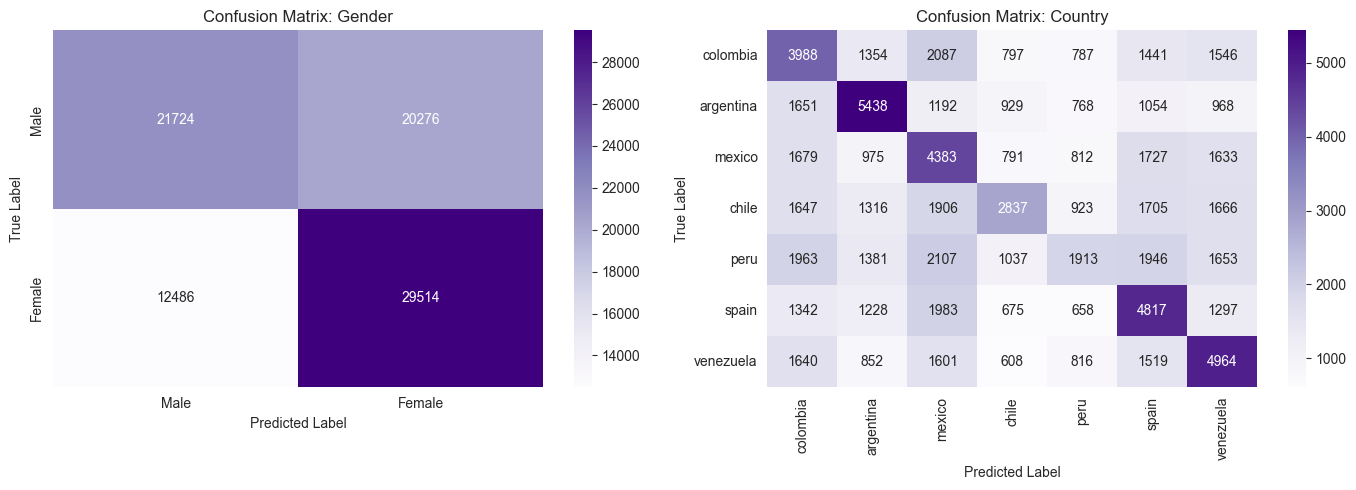

In [12]:
train_results, val_results = Evaluation.evaluate_best_model(trainer, train_dataloader, val_dataloader)

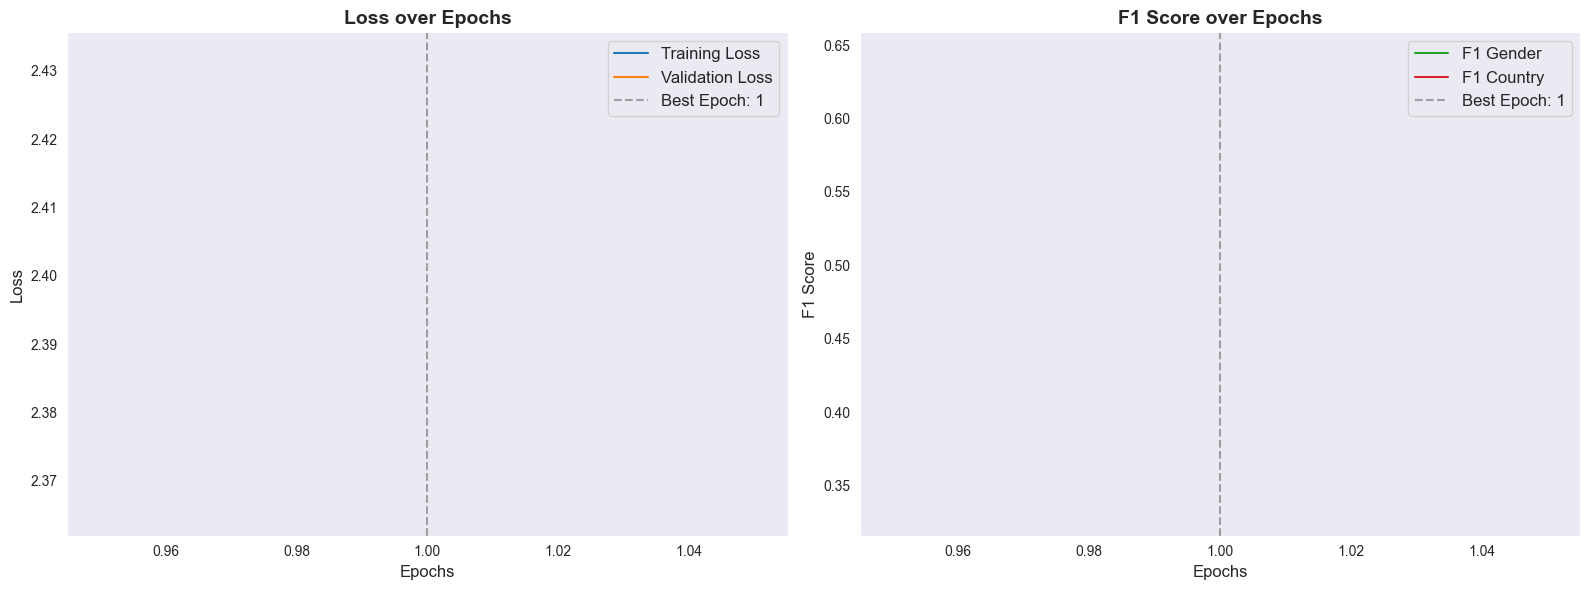

In [13]:
trainer.plot_metrics()

# **5.- (30pts) Discuta brevemente el rendimiento del modelo anterior. Para el punto anterior, construya algunas visualizaciones como en la Figura 6 del paper de atención jerárquica y discuta.**

# **6.- (20pts) Conteste lo siguiente MUY brevemente:**

### **6.1.- ¿Qué representación de términos uso el profesor para participar? http://ceur-ws.org/Vol-1866/paper_109.pdf**

### **6.2.- ¿Qué usó el primer lugar de la competencia? (Basile, et al.) (Consulte: http://ceur-ws.org/Vol-1866/)**

### **6.3.- ¿Cuántos y que competidores usaron deep learning? En una o dos oraciones escriba qué hicieron: https://ceur-ws.org/Vol-1866/**

# **7.- (10pts) extra (Máxima Calificación 110%) para esta tarea: haga una comparación que muestre si la atención en jerarquía es util vs no tenerla (e.g., sin atención o tener un solo nivel de atención)**